### Introduction to Matplotlib 

In [2]:
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

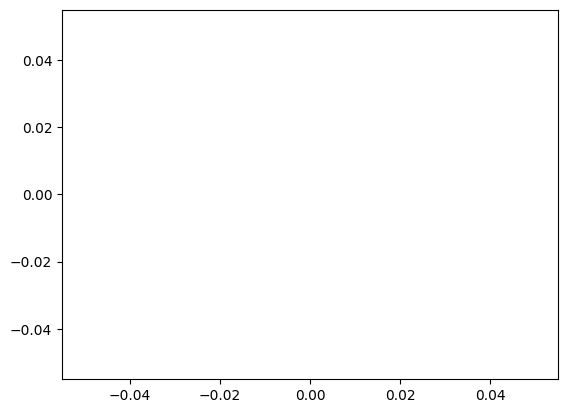

In [12]:
plt.plot()
plt.show()

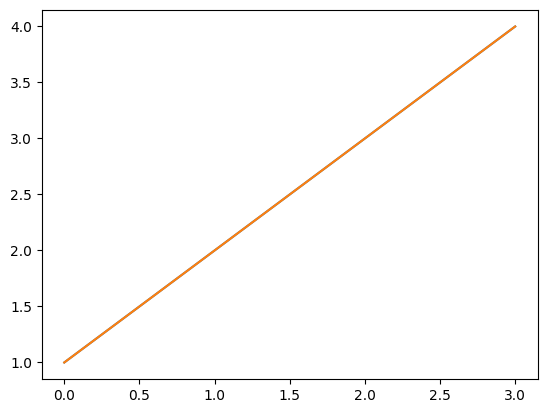

In [14]:
plt.plot([1,2,3,4]);
plt.show()

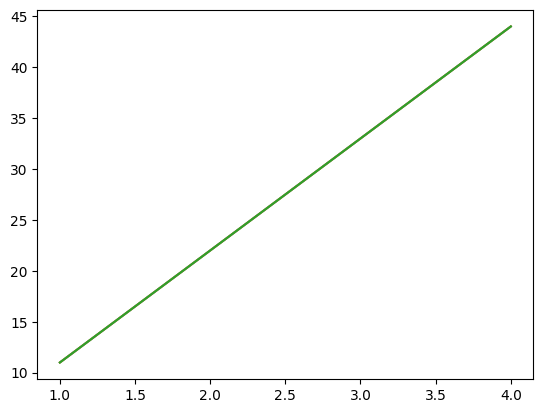

In [17]:
x = [1,2,3,4]
y = [11,22,33,44]
plt.plot(x,y);
plt.show()

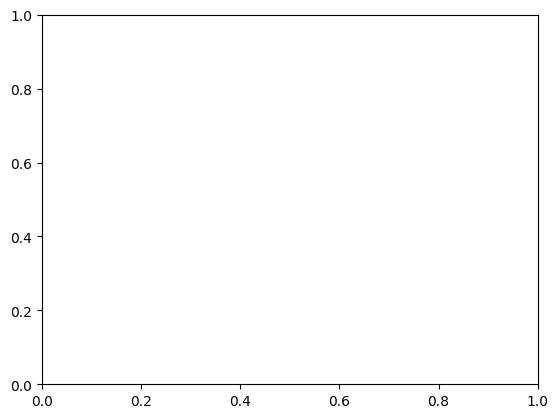

In [19]:
# 1st method
fig = plt.figure() #creates a figure 
ax = fig.add_subplot() # add some axes 
plt.show()

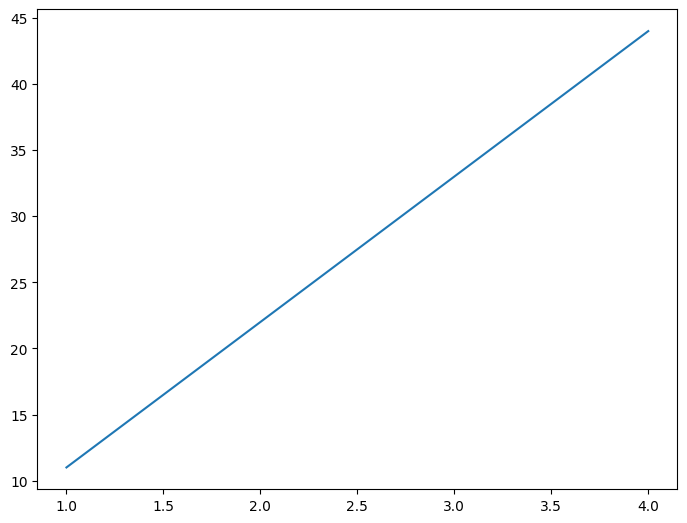

In [29]:
# 2nd method 
fig = plt.figure() #creates a figure
ax = fig.add_axes([1,1,1,1])
ax.plot(x,y); #add some data
plt.show()

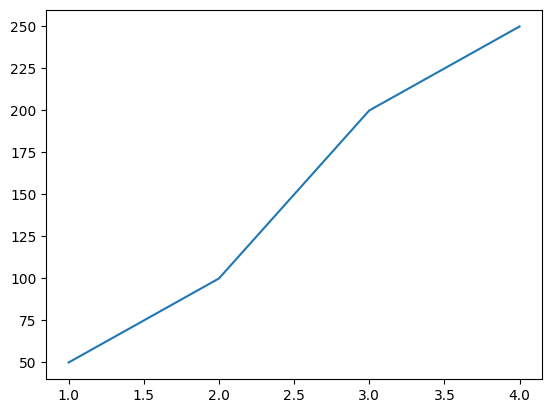

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

In [31]:
# 3rd method (recomanded)
fig,ax = plt.subplots()
ax.plot(x,[50 , 100 , 200 , 250]); # add some data
plt.show()
type(fig) , type(ax)

## Matplotlib example workflow

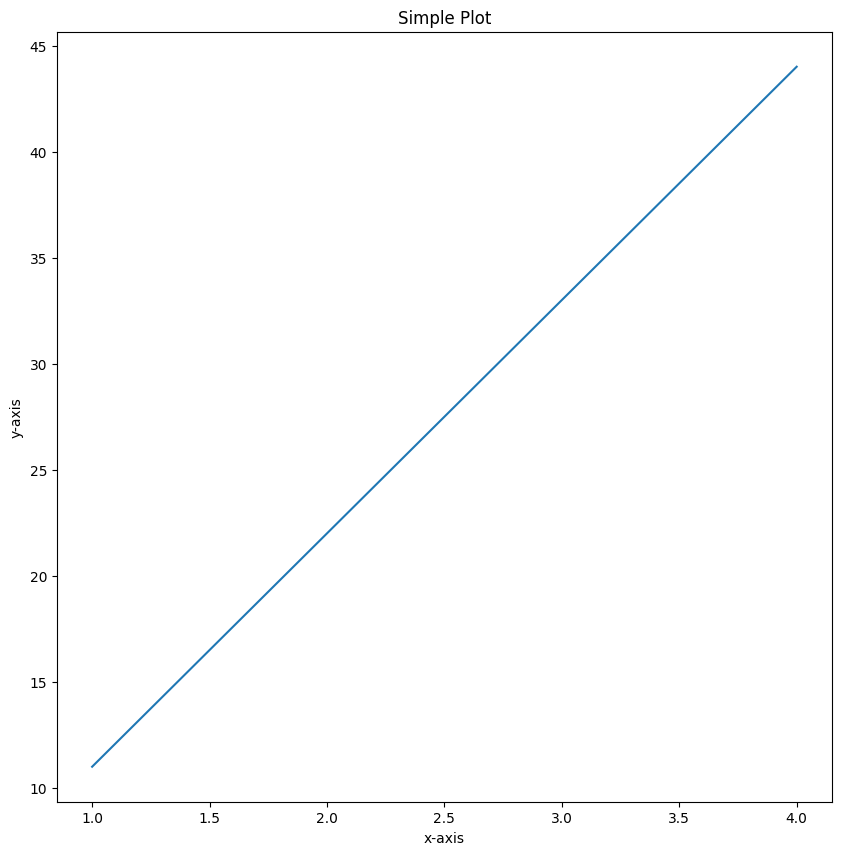

In [45]:
# 0. import matplotlib and get it ready for plotting in Jupyter
%matplotlib inline
import matplotlib.pyplot as plt 

# 1. Prepare data
x = [1 , 2 ,3 ,4]
y = [11 , 22, 33, 44]

# 2. Setup plot
fig , ax = plt.subplots(figsize=(10 ,10)) #(width , height)

# 3. PLot data
ax.plot(x, y)

# 4. Customize plot
ax.set(title="Simple Plot" , xlabel="x-axis" , ylabel="y-axis")

# 5. Save & show (you save the figure)
#fig.savefig("plots/sample_plot.png")
plt.show();

## Making figures with NumPy arrays
We want :
* Line plot
* Scatter plot
* Bar plot
* Histogram
* Subplots

In [40]:
import numpy as np

In [50]:
# Create some data 
x = np.linspace(0 , 10 , 100)
x[:10]

array([0.        , 0.1010101 , 0.2020202 , 0.3030303 , 0.4040404 ,
       0.50505051, 0.60606061, 0.70707071, 0.80808081, 0.90909091])

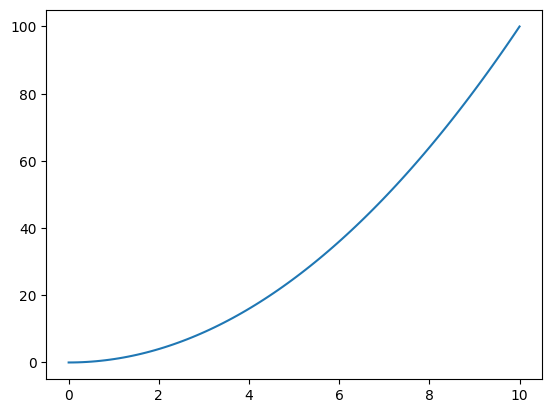

In [51]:
# Plot the data 
fix , ax = plt.subplots()
ax.plot(x , x**2)
plt.show();

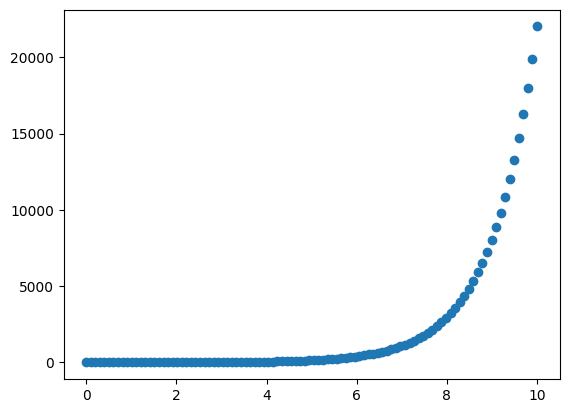

In [52]:
# Use same data to make a scatter
fig , ax = plt.subplots()
ax.scatter(x , np.exp(x))
plt.show();

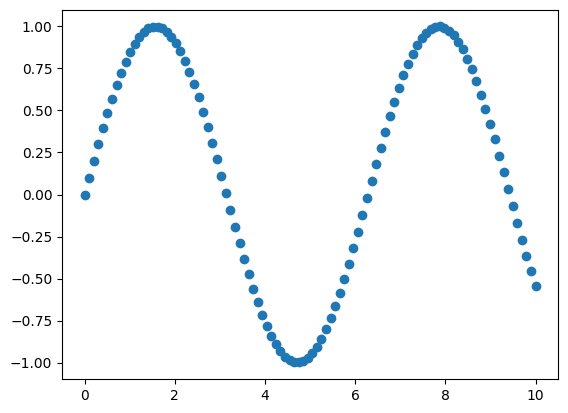

In [53]:
# Another scatter plot
fix , ax = plt.subplots()
ax.scatter(x , np.sin(x))
plt.show()

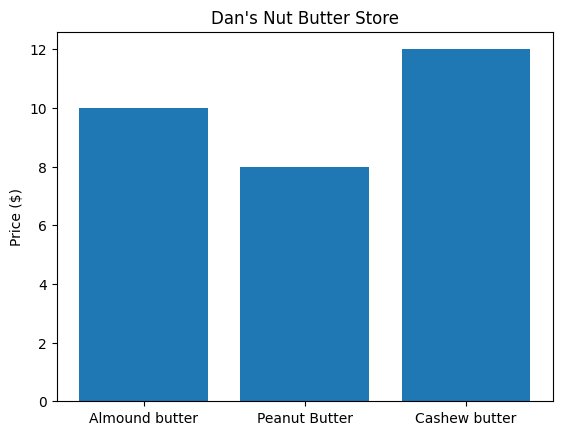

In [58]:
# Make a plot from dictionary
nut_butter_prices = {"Almound butter":10, "Peanut Butter":8, "Cashew butter":12}

fig , ax = plt.subplots()
ax.bar(nut_butter_prices.keys() , nut_butter_prices.values()) #(x,y)
ax.set(title="Dan's Nut Butter Store" , ylabel="Price ($)")
plt.show();

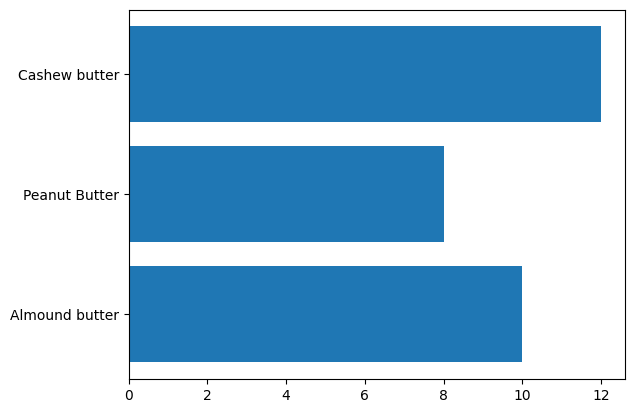

In [61]:
fix , ax = plt.subplots()
ax.barh(list(nut_butter_prices.keys()) , list(nut_butter_prices.values()))
plt.show();

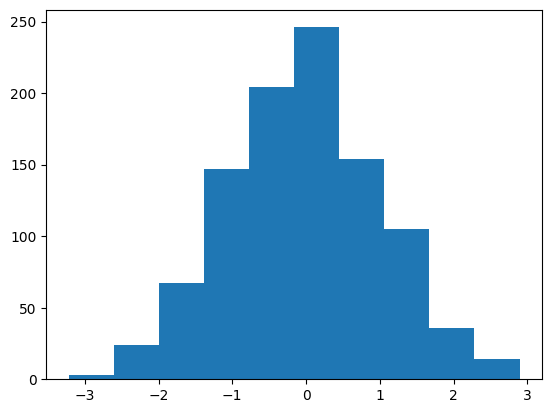

In [62]:
# Make some data
x = np.random.randn(1000)
fix , ax = plt.subplots() 
ax.hist(x);
plt.show();

## Two options for histograms and plot it

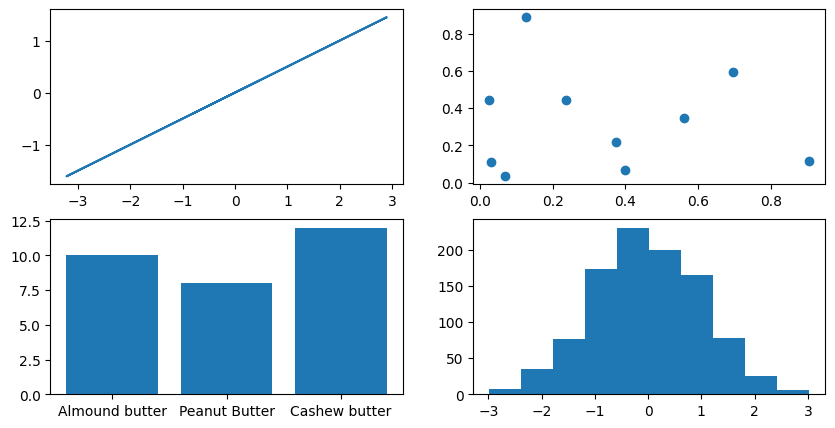

In [68]:
# Subplot option 1
fig , ((ax1 , ax2) , (ax3 , ax4)) = plt.subplots(nrows=2 , ncols=2 , figsize=(10,5))

# Plot to each different exis
ax1.plot(x , x/2);
ax2.scatter(np.random.random(10) , np.random.random(10));
ax3.bar(nut_butter_prices.keys() , nut_butter_prices.values());
ax4.hist(np.random.randn(1000));

plt.show();

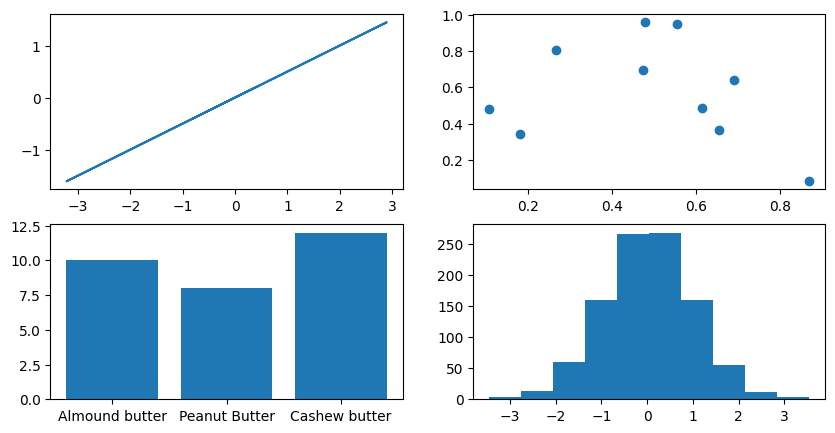

In [69]:
# Subplot option 2 
fig , ax = plt.subplots(nrows=2 , ncols=2 , figsize=(10,5))
# Plot to each different index
ax[0,0].plot(x , x/2);
ax[0,1].scatter(np.random.random(10) , np.random.random(10));
ax[1,0].bar(nut_butter_prices.keys() , nut_butter_prices.values());
ax[1,1].hist(np.random.randn(1000));

plt.show();

## Plotting from pandas DataFrames

In [70]:
import pandas as pd

In [57]:
# Make a dataframe
car_sales = pd.read_csv("csv_datasets/car-sales.csv")
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


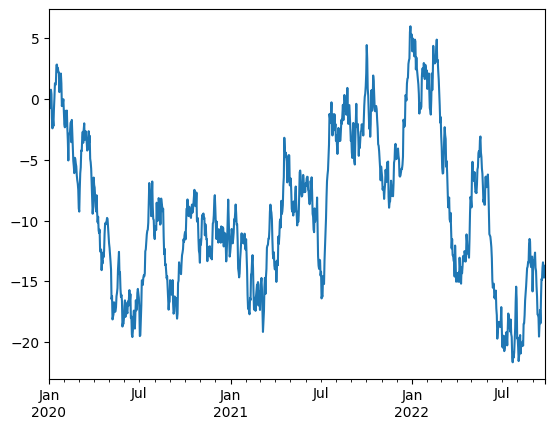

In [81]:
ts = pd.Series(np.random.randn(1000),
               index=pd.date_range("1/1/2020" , periods=1000))
ts = ts.cumsum()
ts.plot()
plt.show();

In [102]:
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$\,\.]' , '' , regex=True)
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000
5,Toyota,Green,99213,4,450000
6,Honda,Blue,45698,4,750000
7,Honda,Blue,54738,4,700000
8,Toyota,White,60000,4,625000
9,Nissan,White,31600,4,970000


In [103]:
# Remove last two zeros
car_sales["Price"] = car_sales["Price"].str[:-2]
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,Toyota,Blue,32549,3,7000
3,BMW,Black,11179,5,22000
4,Nissan,White,213095,4,3500
5,Toyota,Green,99213,4,4500
6,Honda,Blue,45698,4,7500
7,Honda,Blue,54738,4,7000
8,Toyota,White,60000,4,6250
9,Nissan,White,31600,4,9700


In [104]:
car_sales["Sale Date"] = pd.date_range("1/1/2020" , periods = len(car_sales))
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date
0,Toyota,White,150043,4,4000,2020-01-01
1,Honda,Red,87899,4,5000,2020-01-02
2,Toyota,Blue,32549,3,7000,2020-01-03
3,BMW,Black,11179,5,22000,2020-01-04
4,Nissan,White,213095,4,3500,2020-01-05
5,Toyota,Green,99213,4,4500,2020-01-06
6,Honda,Blue,45698,4,7500,2020-01-07
7,Honda,Blue,54738,4,7000,2020-01-08
8,Toyota,White,60000,4,6250,2020-01-09
9,Nissan,White,31600,4,9700,2020-01-10


In [105]:
car_sales["Total Sales"] = car_sales["Price"].astype(int).cumsum()
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2020-01-01,4000
1,Honda,Red,87899,4,5000,2020-01-02,9000
2,Toyota,Blue,32549,3,7000,2020-01-03,16000
3,BMW,Black,11179,5,22000,2020-01-04,38000
4,Nissan,White,213095,4,3500,2020-01-05,41500
5,Toyota,Green,99213,4,4500,2020-01-06,46000
6,Honda,Blue,45698,4,7500,2020-01-07,53500
7,Honda,Blue,54738,4,7000,2020-01-08,60500
8,Toyota,White,60000,4,6250,2020-01-09,66750
9,Nissan,White,31600,4,9700,2020-01-10,76450


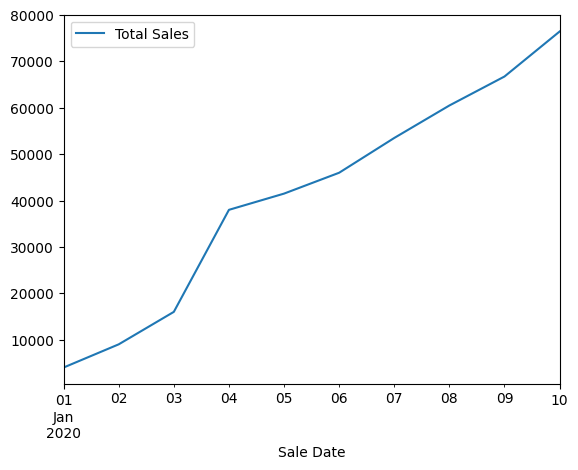

In [108]:
# Let's plot the total sales
car_sales.plot(x="Sale Date" , y="Total Sales");
plt.show();

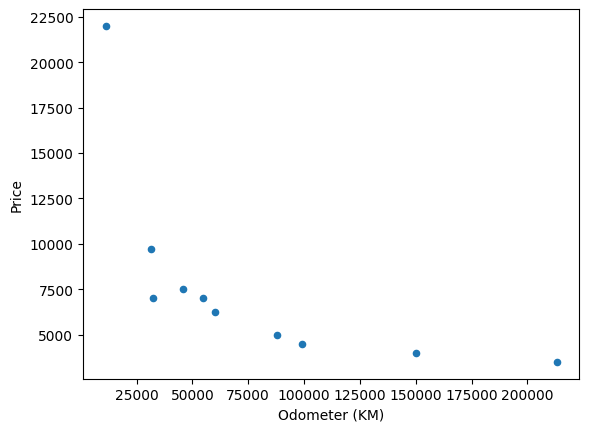

In [110]:
# Reassign price column to int
car_sales["Price"] = car_sales["Price"].astype(int)

#Plot scatter plot with price column as numeric
car_sales.plot(x="Odometer (KM)" , y="Price" , kind="scatter")
plt.show();

In [111]:
# How about a bar graph
x = np.random.rand(10 , 4)
x

#Turn it into a dataframe
df = pd.DataFrame(x , columns=['a' , 'b' , 'c', 'd'])
df

,a,b,c,d
0,0.808385,0.994980,0.135664,0.820330
1,0.498730,0.882761,0.236077,0.611961
2,0.280553,0.858987,0.545689,0.393430
3,0.609030,0.028458,0.996013,0.313799
4,0.201954,0.112055,0.650800,0.730834
5,0.007179,0.746854,0.266182,0.135308
6,0.987819,0.183795,0.924166,0.904676
7,0.666052,0.192710,0.699491,0.742316
8,0.025339,0.919206,0.990244,0.214287
9,0.015361,0.844375,0.700061,0.883370


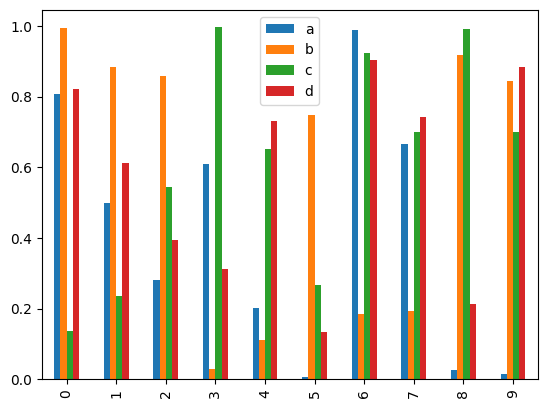

In [114]:
df.plot.bar();
plt.show();

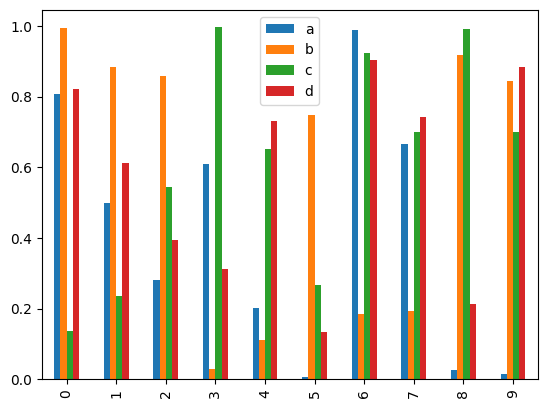

In [115]:
df.plot(kind="bar")
plt.show();

In [116]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2020-01-01,4000
1,Honda,Red,87899,4,5000,2020-01-02,9000
2,Toyota,Blue,32549,3,7000,2020-01-03,16000
3,BMW,Black,11179,5,22000,2020-01-04,38000
4,Nissan,White,213095,4,3500,2020-01-05,41500
5,Toyota,Green,99213,4,4500,2020-01-06,46000
6,Honda,Blue,45698,4,7500,2020-01-07,53500
7,Honda,Blue,54738,4,7000,2020-01-08,60500
8,Toyota,White,60000,4,6250,2020-01-09,66750
9,Nissan,White,31600,4,9700,2020-01-10,76450


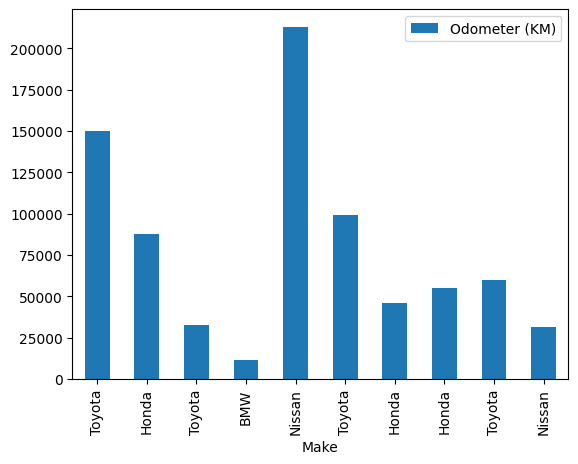

In [117]:
car_sales.plot(x="Make" , y="Odometer (KM)" , kind="bar")
plt.show();

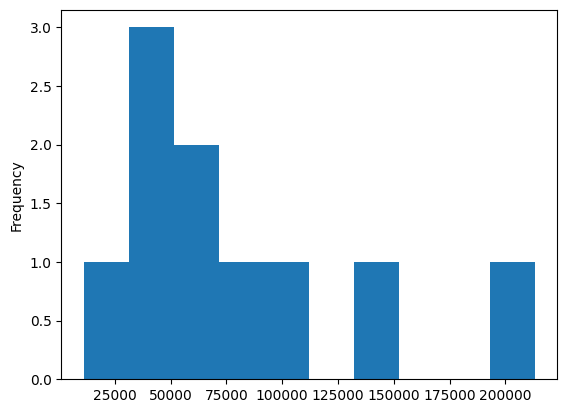

In [120]:
# How about histograms ?
car_sales["Odometer (KM)"].plot.hist()
plt.show();

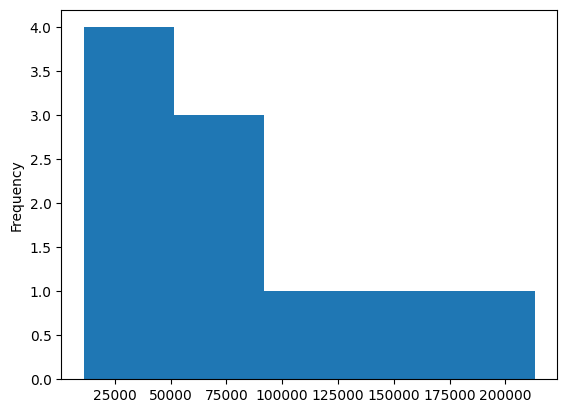

In [121]:
car_sales["Odometer (KM)"].plot.hist(bins=5)
plt.show();

In [6]:
heart_disease = pd.read_csv('csv_datasets/heart-disease.csv')
heart_disease.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


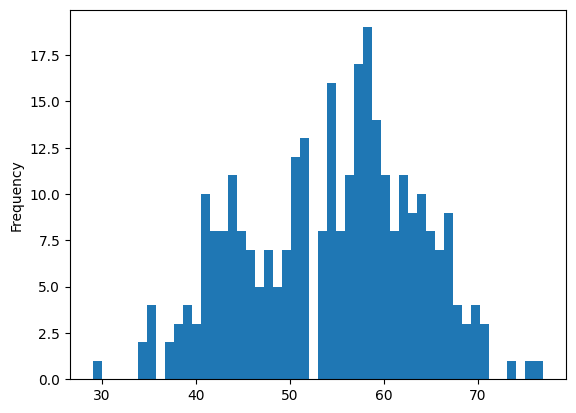

In [8]:
# Create a histogram of age
heart_disease["age"].plot.hist(bins=50)
plt.show();

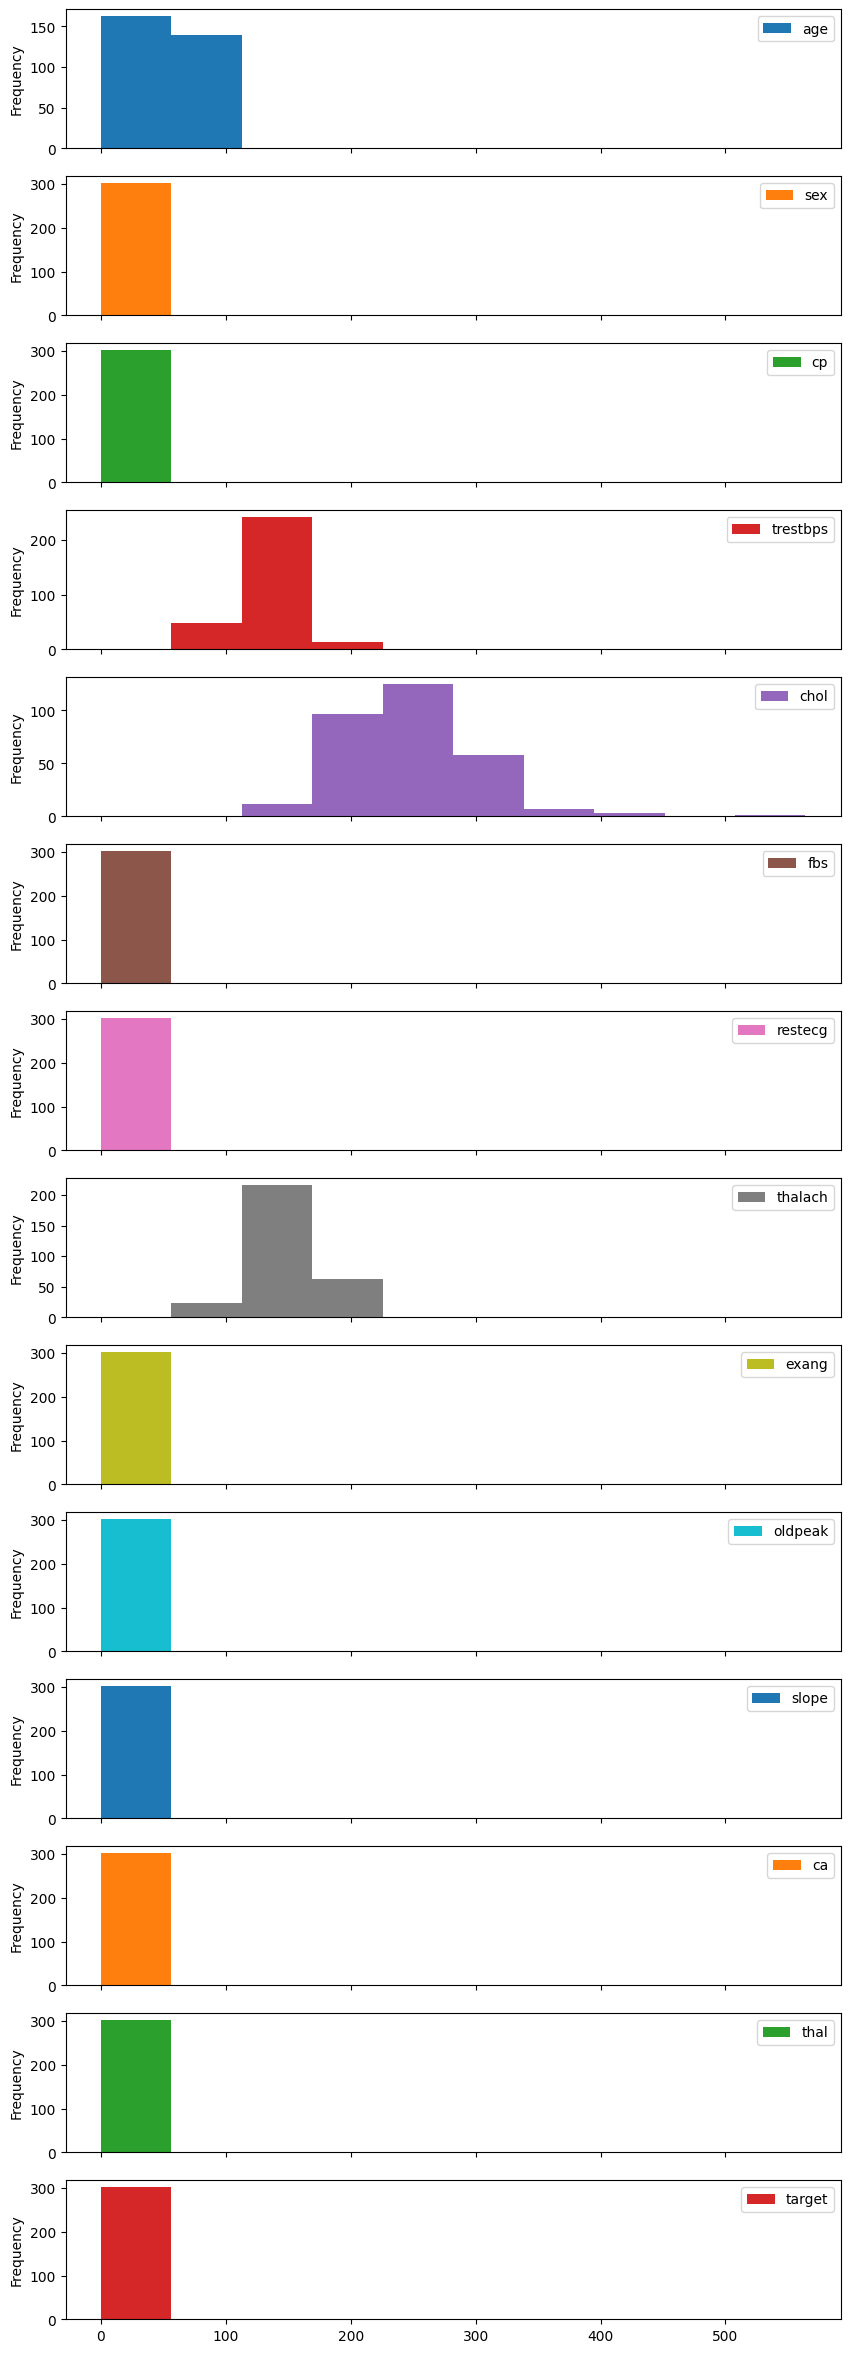

In [10]:
heart_disease.plot.hist(figsize=(10 , 30) , subplots=True)
plt.show();

### Wich one should you use ? (pyplot & matplotlib OO method)

* When plotting something quickly , okay to use the pyplot method 
* When plotting something more advance , use OO method

In [12]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
over_50 = heart_disease[heart_disease["age"] > 50]
over_50.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1


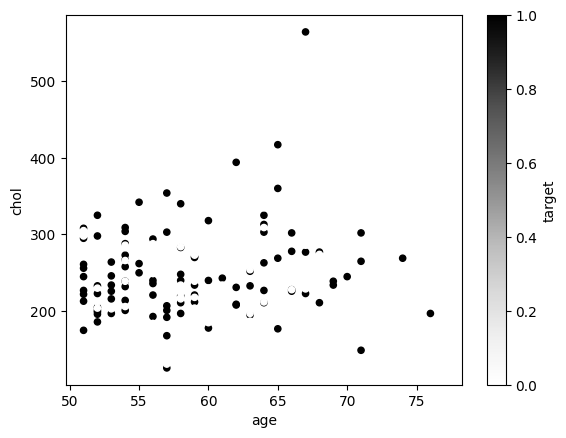

In [18]:
#Pyplot method
over_50.plot(kind='scatter' , x = 'age' , y='chol' , c='target');
plt.show();

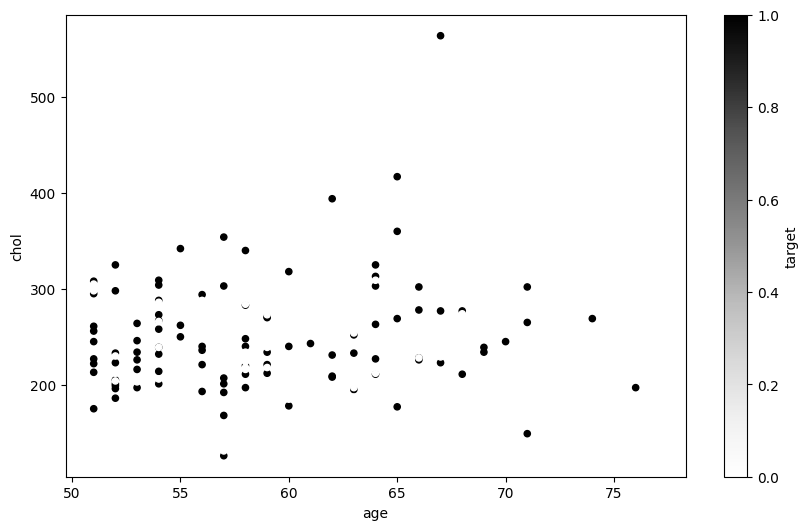

In [21]:
# OO method
fix , ax = plt.subplots(figsize=(10,6))
over_50.plot(kind="scatter" , x="age" , y="chol" , c="target" , ax=ax );

#ax.set_xlim([45,100])
plt.show();

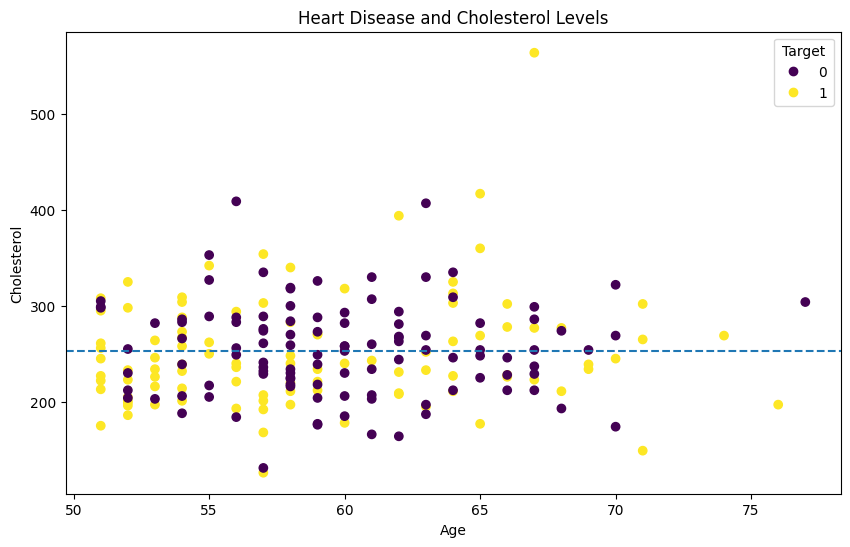

In [25]:
# OO method from scratch
fix , ax = plt.subplots(figsize=(10,6))

# Plot the data
scatter = ax.scatter(x=over_50["age"] , y=over_50["chol"] , c=over_50["target"]);

#Customize the plot
ax.set(title="Heart Disease and Cholesterol Levels",xlabel="Age",ylabel="Cholesterol");

#Add a legend
ax.legend(*scatter.legend_elements() , title="Target");

# Add a horizontal line
ax.axhline(over_50["chol"].mean() , linestyle="--")

plt.show();

In [9]:
over_50.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1


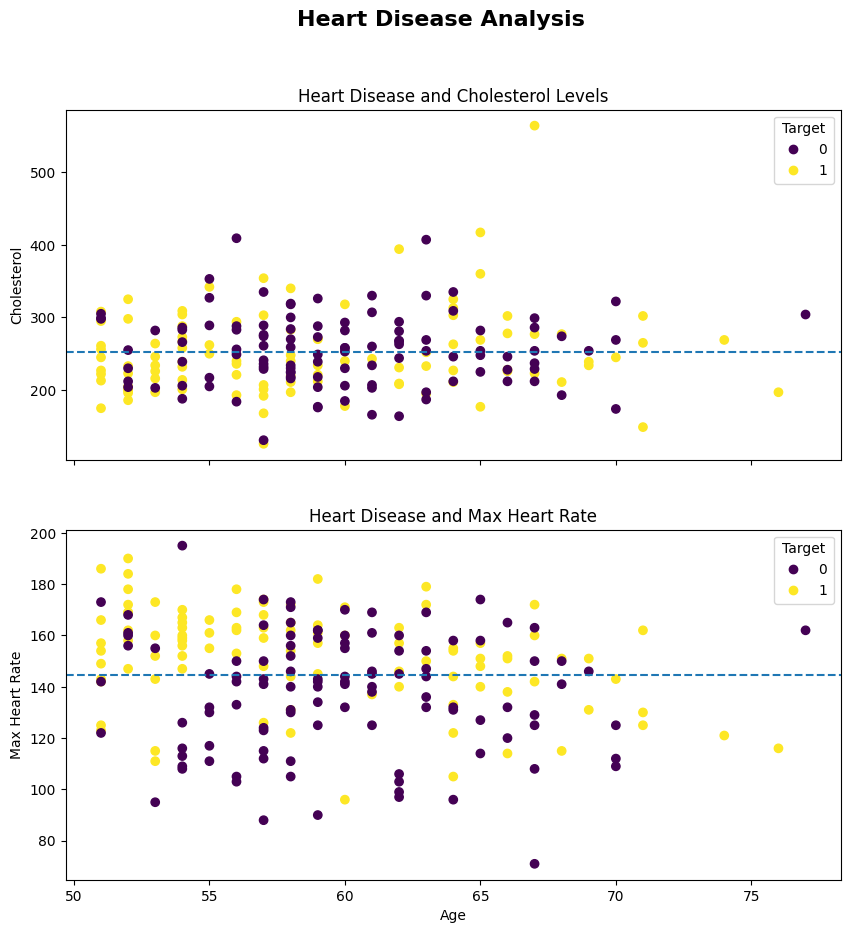

In [54]:
# Subplot of chol , age , thalach
fig , (ax0 , ax1) = plt.subplots(nrows=2 , ncols=1 , figsize=(10,10) , sharex=True)

#Add data to ax0
scatter = ax0.scatter( x=over_50["age"] , y=over_50["chol"], c=over_50["target"])

#Customize ax0
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol");

ax0.axhline(y=over_50["chol"].mean(),linestyle='--');

#Add a legend to ax0
ax0.legend(*scatter.legend_elements() , title="Target")

# Add data to ax1
scatter = ax1.scatter(x=over_50["age"] , y=over_50["thalach"] , c=over_50["target"])

# Customize ax1
ax1.set(title="Heart Disease and Max Heart Rate" , xlabel="Age" , ylabel="Max Heart Rate")

# Add a legend to ax1
ax1.axhline(y=over_50["thalach"].mean(),linestyle='--');

#Add a legend to ax1
ax1.legend(*scatter.legend_elements() , title="Target")

#Add a title to a figure 
fig.suptitle("Heart Disease Analysis" , fontsize=16 , fontweight="bold");

plt.show();

## Customizing Matplotlib plots and getting stylish 

In [55]:
# See the different styles available
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [72]:
car_sales["Price"] = car_sales["Price"].astype(str).str.replace(r'[\$\,\.]', '', regex=True).astype(int)
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000


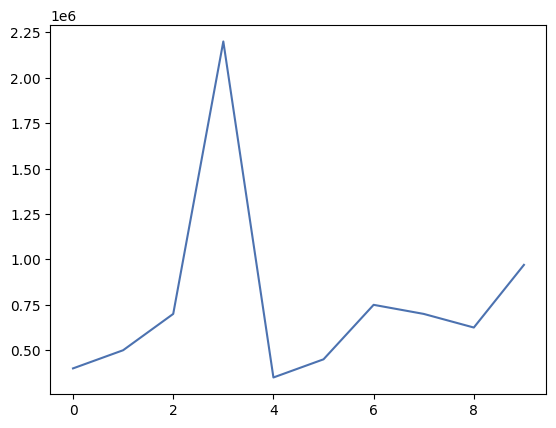

In [76]:
plt.style.use('seaborn-v0_8-deep')
car_sales["Price"].plot();
plt.show();

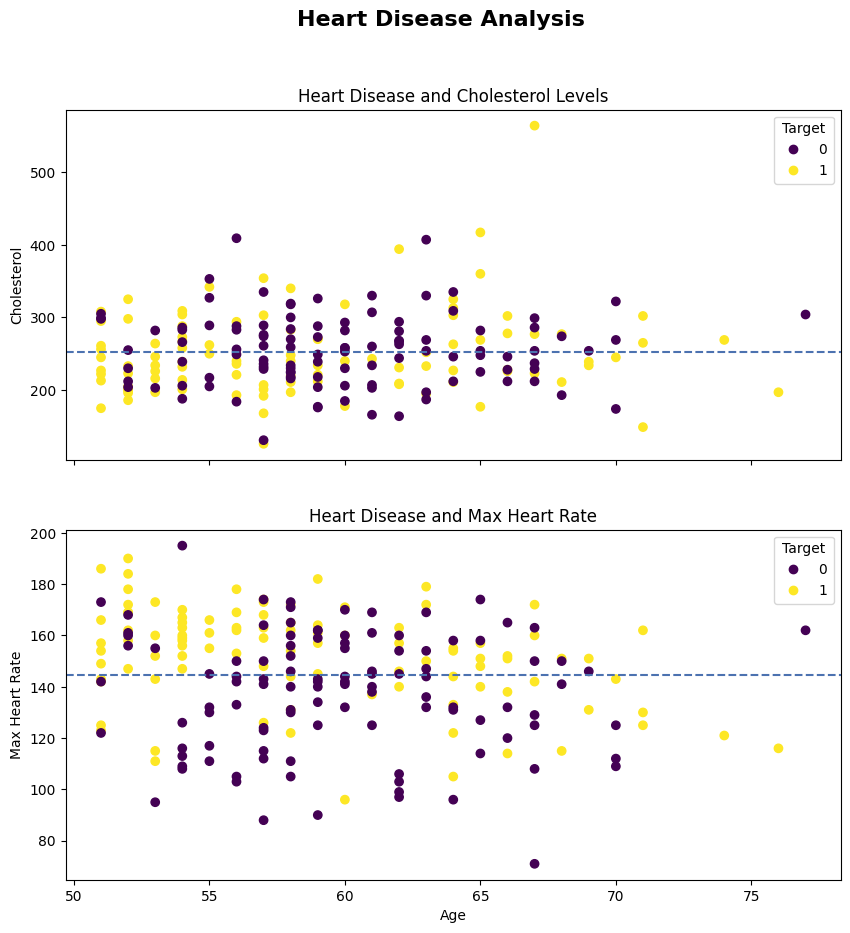

In [77]:
fig

In [78]:
# To save plot
# fig.savefig("name.png")